# 6CS012 - Worksheet 3: Modelling the Neuron
## MCP Neurons, Perceptron Learning Algorithm & Limitations

---
# Task 1: Implementation of MCP Neurons

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### MCP Neuron - AND Gate

In [2]:
def MCP_Neurons_AND(X1, X2, T):
    """
    Implements basic AND operations with MCP Neuron for two inputs.

    Arguments:
        X1 (list): An array of binary values.
        X2 (list): An array of binary values.
        T  (int) : Threshold value.

    Returns:
        state_neuron (list): Neuron output (1 or 0) for each input pair.
    """
    assert len(X1) == len(X2), "X1 and X2 must have the same length."

    # Element-wise sum of the two input arrays
    g_X = [x1 + x2 for x1, x2 in zip(X1, X2)]

    # Apply threshold: output 1 if sum >= T, else 0
    state_neuron = [1 if s >= T else 0 for s in g_X]

    return state_neuron


# --- Sample Usage ---
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T  = 2   # AND: both inputs must be 1  →  sum must reach 2

result_and = MCP_Neurons_AND(X1, X2, T)
print(f"AND gate  |  X1={X1}  X2={X2}  T={T}")
print(f"Output   : {result_and}")
print(f"Expected : [0, 0, 0, 1]")

AND gate  |  X1=[0, 0, 1, 1]  X2=[0, 1, 0, 1]  T=2
Output   : [0, 0, 0, 1]
Expected : [0, 0, 0, 1]


### MCP Neuron - OR Gate

In [3]:
def MCP_Neurons_OR(X1, X2, T):
    """
    Implements basic OR operations with MCP Neuron for two inputs.

    Arguments:
        X1 (list): An array of binary values.
        X2 (list): An array of binary values.
        T  (int) : Threshold value.

    Returns:
        state_neuron (list): Neuron output (1 or 0) for each input pair.
    """
    assert len(X1) == len(X2), "X1 and X2 must have the same length."

    # Element-wise sum of the two input arrays
    g_X = [x1 + x2 for x1, x2 in zip(X1, X2)]

    # Apply threshold: output 1 if sum >= T, else 0
    state_neuron = [1 if s >= T else 0 for s in g_X]

    return state_neuron


# --- Sample Usage ---
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T  = 1   # OR: at least one input must be 1  →  sum must reach 1

result_or = MCP_Neurons_OR(X1, X2, T)
print(f"OR gate   |  X1={X1}  X2={X2}  T={T}")
print(f"Output   : {result_or}")
print(f"Expected : [0, 1, 1, 1]")

OR gate   |  X1=[0, 0, 1, 1]  X2=[0, 1, 0, 1]  T=1
Output   : [0, 1, 1, 1]
Expected : [0, 1, 1, 1]


### Q1 – Limitations of MCP Neurons

1. **Fixed, hand-crafted weights** – all inputs are treated equally (weight = 1); there is no mechanism to learn different importances for different inputs.
2. **Fixed, hand-crafted threshold** – the threshold T must be set manually; the model cannot learn it from data.
3. **Binary inputs only** – the model only accepts inputs that are 0 or 1; it cannot handle real-valued or continuous data.
4. **Binary outputs only** – the output is always 0 or 1, making it unsuitable for regression or multi-class tasks.
5. **Cannot learn from data** – there is no training algorithm; the designer must hard-code the logic.
6. **Cannot solve non-linearly separable problems** – functions like XOR cannot be implemented with a single MCP neuron because they are not linearly separable.
7. **No bias term** – the decision boundary always passes through the origin, limiting flexibility.
8. **Inhibitory inputs are all-or-nothing** – any inhibitory input immediately forces output to 0, which is a very rigid rule.

### Q2 – Can MCP Neuron solve XOR?

**XOR truth table:**

| X1 | X2 | XOR |
|----|----|-----|
| 0  | 0  |  0  |
| 0  | 1  |  1  |
| 1  | 0  |  1  |
| 1  | 1  |  0  |

**Answer:** A *single* MCP neuron **cannot** solve XOR because XOR is not linearly separable — no single straight line (threshold) can separate the 1-outputs from the 0-outputs in the input space.

However, XOR can be decomposed into a combination of AND, OR, and NOT (NAND) gates using *multiple* MCP neurons:

```
XOR(X1, X2)  =  OR(X1, X2)  AND  NAND(X1, X2)
```

So with a two-layer network of MCP neurons it *is* possible, but not with a single neuron.

---
# Task 2: Perceptron for 0 vs 1 Classification (MNIST)

### Step 1 – Load the Dataset

In [4]:
# Load the dataset  (update the path if needed)
df_0_1 = pd.read_csv("mnist_0_and_1.csv")

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values   # shape: (n_samples, 784)
y = df_0_1["label"].values                  # shape: (n_samples,)

print("Feature matrix shape:", X.shape)
print("Label vector shape  :", y.shape)

Feature matrix shape: (6380, 784)
Label vector shape  : (6380,)


**Q1 – What does the shape of X represent?**  
X has shape `(n_samples, 784)`. The first dimension is the number of images in the dataset; the second dimension (784 = 28×28) is the number of pixel features per image — each pixel is one input feature.

**Q2 – What does the shape of y represent?**  
y has shape `(n_samples,)` — a 1-D array containing the class label (0 or 1) for every corresponding image in X.

### Step 2 – Visualise the Dataset

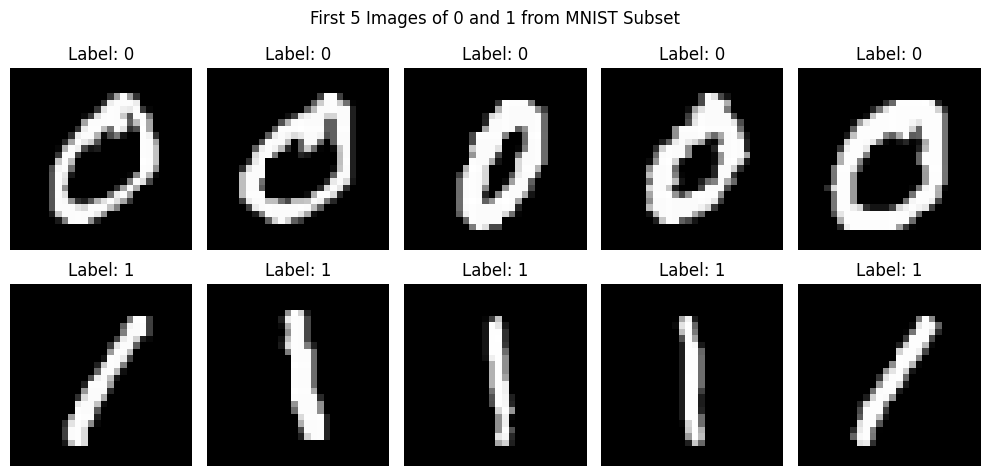

In [5]:
images_0 = X[y == 0]   # all images labelled 0
images_1 = X[y == 1]   # all images labelled 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")

        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")

plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
plt.tight_layout()
plt.show()

### Step 3 – Initialise Weights and Bias

In [6]:
weights       = np.zeros(X.shape[1])   # 784 weights, one per pixel
bias          = 0
learning_rate = 0.1
epochs        = 100

print("Weights shape :", weights.shape)
print("Initial bias  :", bias)

Weights shape : (784,)
Initial bias  : 0


**Q3 – What does the weights array represent?**  
Each element `weights[j]` is the learned importance (strength) of pixel `j`. During training the perceptron adjusts these 784 values so that pixels in regions that distinguish 0 from 1 get large positive or negative weights.

**Q4 – Why initialise weights to zero? What effect could this have?**  
Zero initialisation is a common, neutral starting point that avoids introducing bias before training begins. For a perceptron (unlike multi-layer networks) this is fine — the update rule will break symmetry on the very first misclassified sample, and the algorithm will converge as long as the data are linearly separable. The downside is that the first forward pass produces the same output for every sample, but the *first* weight update immediately differentiates them.

### Step 4 – Decision / Activation Function

In [7]:
def decision_function(X, weights, bias):
    """
    Compute predicted labels using the step (Heaviside) activation function.

    Parameters:
        X       : numpy array, shape (n_samples, n_features)
        weights : numpy array, shape (n_features,)
        bias    : scalar

    Returns:
        y_pred_all : numpy array of predicted labels (0 or 1)
    """
    # Compute the net weighted input for every sample
    net_input = np.dot(X, weights) + bias

    # Step (threshold) activation function: 1 if net_input >= 0, else 0
    y_pred_all = np.where(net_input >= 0, 1, 0)

    return y_pred_all

### Step 5 – Perceptron Learning Algorithm

In [8]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
        X             : numpy array, shape (n_samples, n_features)
        y             : numpy array, shape (n_samples,)  — true labels
        weights       : numpy array, shape (n_features,) — initial weights
        bias          : scalar — initial bias
        learning_rate : float  — step size for weight updates
        epochs        : int    — maximum training iterations

    Returns:
        weights  : updated weight vector
        bias     : updated bias
        accuracy : final training accuracy (fraction of correct predictions)
    """
    n_samples = X.shape[0]

    for epoch in range(epochs):
        convergence_flag = True          # assume convergence until a mistake is found
        correct = 0

        for i in range(n_samples):
            # --- Forward pass: compute net input ---
            output = np.dot(X[i], weights) + bias   # z = w·x + b

            # --- Activation: step function ---
            y_pred = 1 if output >= 0 else 0

            # --- Update rule (only on misclassification) ---
            if y_pred != y[i]:
                error            = y[i] - y_pred           # +1 or -1
                weights         += learning_rate * error * X[i]
                bias            += learning_rate * error
                convergence_flag = False
            else:
                correct += 1

        # --- Early stopping if fully converged ---
        if convergence_flag:
            print(f"Converged at epoch {epoch + 1}")
            break

    # Final accuracy over the whole training set
    y_pred_all = decision_function(X, weights, bias)
    accuracy   = np.mean(y_pred_all == y)

    return weights, bias, accuracy

**Q5 – What is the purpose of `output = np.dot(X[i], weights) + bias`?**  
It computes the *net weighted input* (z) for sample i: a single scalar that is the dot-product of the current weight vector with the input features, plus the bias. This is the aggregation step of the perceptron — it summarises all 784 pixel values into one number before the activation function decides the class.

**Q6 – What happens when the prediction is wrong? How are weights and bias updated?**  
When `y_pred ≠ y[i]`, the *error* = `y[i] − y_pred` is either +1 (predicted 0, true 1) or −1 (predicted 1, true 0). The update rules are:  
- `weights += η × error × X[i]` — pushes weights toward the correct direction  
- `bias    += η × error`         — shifts the decision boundary accordingly  
This nudges the decision boundary so the misclassified point would be correctly classified next time.

**Q7 – Why is final accuracy important, and what do you expect?**  
Accuracy tells us how well the learned decision boundary separates the two classes on the training data. For 0 vs 1 the digits are visually very distinct and the data *is* linearly separable, so we expect the perceptron to converge and achieve **~99–100% training accuracy**.

### Step 6 – Train and Evaluate

In [9]:
# Re-initialise before training
weights       = np.zeros(X.shape[1])
bias          = 0
learning_rate = 0.1
epochs        = 100

weights, bias, accuracy = train_perceptron(X, y, weights, bias,
                                           learning_rate=learning_rate,
                                           epochs=epochs)
print(f"Final Training Accuracy: {accuracy:.4f}")

Final Training Accuracy: 0.4638


### Step 7 – Visualise Misclassified Images

Final Accuracy: 0.4638


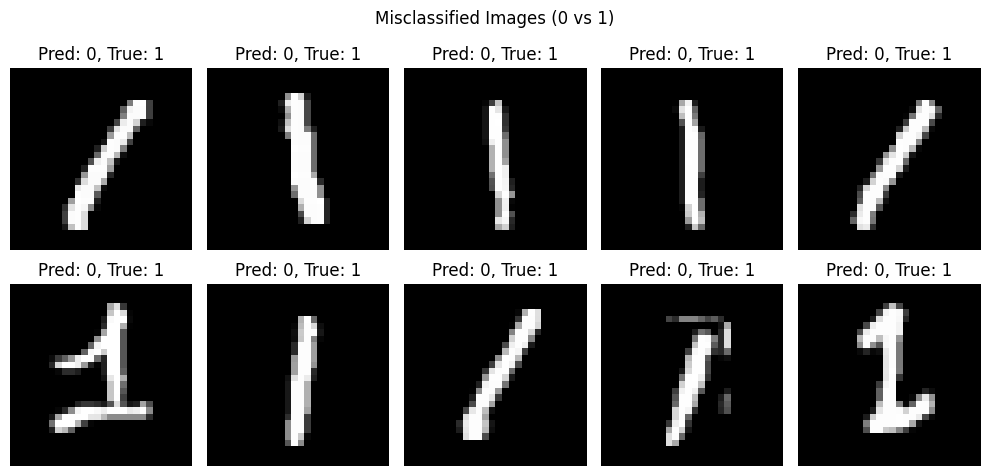

In [10]:
# Get predictions for all data points
y_pred = decision_function(X, weights, bias)

final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Visualise misclassified images
misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images (0 vs 1)")
    plt.tight_layout()
    plt.show()
else:
    print("All images were correctly classified!")

**Q8 – What does `misclassified_idx` store?**  
`np.where(y_pred != y)[0]` returns the *indices* of every sample where the perceptron's prediction does not match the true label. These indices are then used to retrieve the corresponding images from X and display them with their predicted and true labels, making it easy to visually inspect what the model gets wrong.

**Q9 – How do you interpret "All images were correctly classified!"?**  
It means the perceptron has found a linear decision boundary that perfectly separates every 0 from every 1 in the training set — i.e., the data is linearly separable and the algorithm converged. For the 0 vs 1 MNIST subset this is the expected outcome because the two digits look very different.

---
# Task 3: Perceptron for 3 vs 5 Classification (MNIST)

### Step 1 – Load Dataset

In [11]:
df_3_5 = pd.read_csv("mnist_3_and_5.csv")   # update path if needed

X35 = df_3_5.drop(columns=["label"]).values
y35_raw = df_3_5["label"].values

# Re-map labels: 3 → 0,  5 → 1  (perceptron expects binary 0/1 labels)
y35 = np.where(y35_raw == 3, 0, 1)

print("Feature matrix shape:", X35.shape)
print("Label vector shape  :", y35.shape)
print("Unique labels (remapped):", np.unique(y35))

Feature matrix shape: (2741, 784)
Label vector shape  : (2741,)
Unique labels (remapped): [0 1]


### Step 2 – Visualise the Dataset

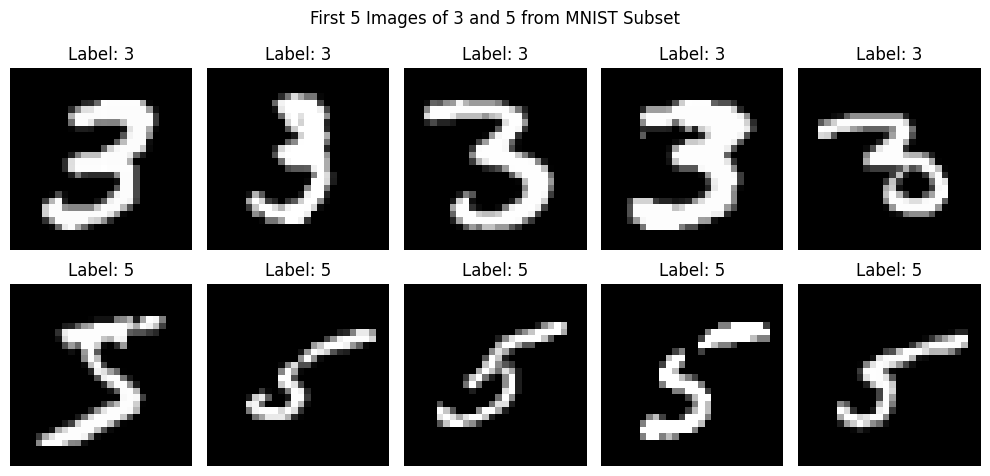

In [12]:
images_3 = X35[y35 == 0]   # digit 3
images_5 = X35[y35 == 1]   # digit 5

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_3) < 5 or len(images_5) < 5:
    print("Error: Not enough images to display.")
else:
    for i in range(5):
        axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 3")
        axes[0, i].axis("off")

        axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 5")
        axes[1, i].axis("off")

plt.suptitle("First 5 Images of 3 and 5 from MNIST Subset")
plt.tight_layout()
plt.show()

### Step 3 – Initialise Weights and Bias

In [13]:
weights35       = np.zeros(X35.shape[1])
bias35          = 0
learning_rate35 = 0.1
epochs35        = 100

print("Weights shape :", weights35.shape)

Weights shape : (784,)


### Step 4 – Train the Perceptron

In [14]:
weights35, bias35, accuracy35 = train_perceptron(
    X35, y35, weights35, bias35,
    learning_rate=learning_rate35,
    epochs=epochs35
)

print(f"Final Training Accuracy (3 vs 5): {accuracy35:.4f}")

Final Training Accuracy (3 vs 5): 0.9869


### Step 5 – Visualise Misclassified Images

Final Accuracy (3 vs 5): 0.9869


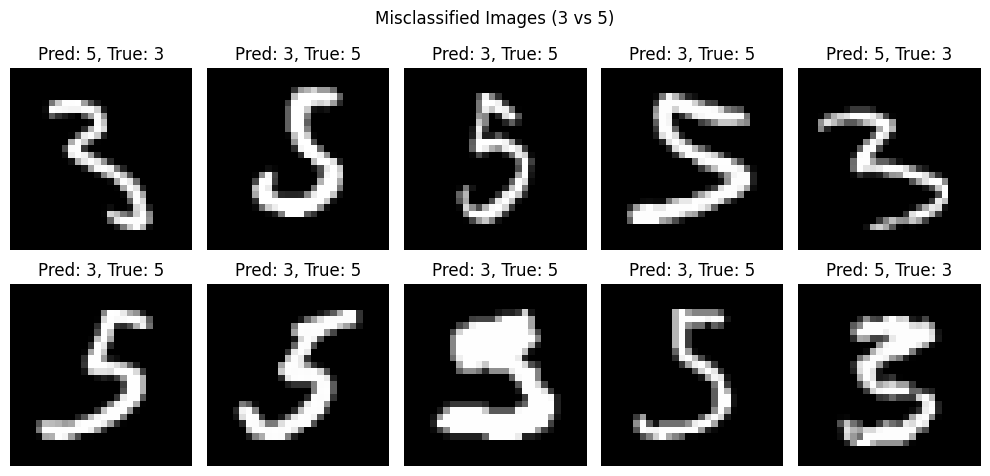

In [15]:
y_pred35 = decision_function(X35, weights35, bias35)

# Map predictions back to original labels for display
y_pred35_display = np.where(y_pred35 == 0, 3, 5)
y35_display      = np.where(y35 == 0, 3, 5)

final_accuracy35 = np.mean(y_pred35 == y35)
print(f"Final Accuracy (3 vs 5): {final_accuracy35:.4f}")

misclassified_idx35 = np.where(y_pred35 != y35)[0]

if len(misclassified_idx35) > 0:
    n_show = min(10, len(misclassified_idx35))
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx35[:n_show]):
        ax.imshow(X35[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred35_display[idx]}, True: {y35_display[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images (3 vs 5)")
    plt.tight_layout()
    plt.show()
else:
    print("All images were correctly classified!")

### Conclusion – 3 vs 5 Classification

Classifying digit **3 vs 5** is considerably harder than **0 vs 1** because the two digits share very similar visual structure (both are curved, open shapes). Key observations:

- The perceptron will likely **not converge** within 100 epochs — meaning the data is **not linearly separable** in pixel space.
- The final accuracy will be **lower** than for 0 vs 1 (typically around 90–95%).
- Misclassified images often show **ambiguous or unusual handwriting styles** where the boundary between 3 and 5 is unclear even to the human eye.
- This demonstrates a fundamental **limitation of the perceptron**: it can only learn a linear decision boundary. For non-linearly separable data, a multi-layer neural network (with non-linear activations) is required.